# Notebook for depth profile algorithm

In [5]:
import numpy as np

import matplotlib.pyplot as plt

import pandas as pd

from scipy.special import erf
from scipy.constants import Julian_year

from scipy.optimize import minimize
%config InlineBackend.figure_format='retina'
%matplotlib inline

In [6]:
C1 = 2000 # ppm
R = 8.314462618
rutile_E = 250*1000
rutile_D0 = 3.9E-10

apatite_E = 54.6*4.184*1000
apatite_D0 = 1.27e-8

def calc_D(D0, E, T):
    return D0*np.exp(-E/R/T)

def calc_c_x_t(x, t, T, C1, D0, E):
    D = calc_D(D0, E, T)
    
    C1*erf(x/np.dqrt(4*D*t))
    return 

## testing Smye 2014 figure 1

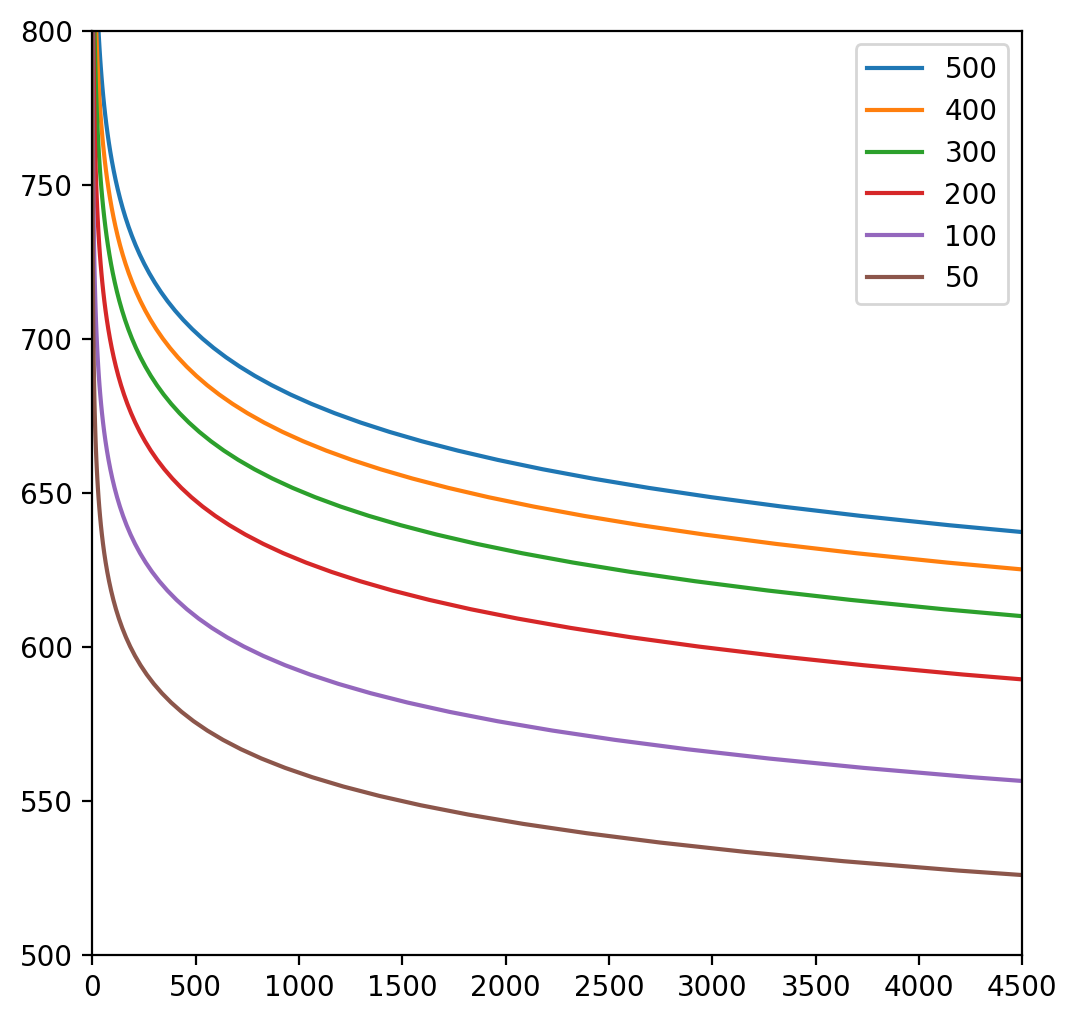

In [7]:
rutile_E = 250*1000

rutile_D0 = 3.9E-10 # m^2s-1

rutile_size_range = [50, 100, 200, 300, 400, 500] #µm
rutile_size_range = rutile_size_range[::-1]
T_range = np.linspace(500, 800, 100)
rutile_D_range = calc_D(rutile_D0, rutile_E, T_range+273.15)

plt.figure(figsize=(6,6))
for rutile_size in rutile_size_range:
    time_range = (rutile_size*1e-6)**2/rutile_D_range/Julian_year/1e6
    plt.plot(time_range, T_range, label=str(rutile_size))

plt.xlim(0, 4500)
plt.ylim(500, 800)

plt.legend()
plt.show()

In [8]:
def Function_UPbDiff(t_nodes,T_nodes,eff238Conc, Ea, D0, r_sphere, num_GridNodes = 512):
    '''
    function to calculation Pb diffusion profile with given time and temperature path, adpoted from Smye et al., 2018
    
    required parameters:
    t_nodes: time nodes of the thermal history profile, in Myr
    T_nodes: temperature nodes of the thermal history profile, in Celsius
    
    gridnode:
    c238: effective concentration of initial U 238 in the grain
    Ea: activity energy of the mineral
    D0: the pre-exponential term of the temperature dependent diffusivity equation for a sepcific mineral
    r_sphere: effetive radius of the grain, in cm
    num_gridnodes: the number of gridnodes (i.e. resolution) used to solve the concentration profile 
    
    '''
#     Decay constants
    lyr238 = 1.55125e-10 # in yr
    l238 = lyr238      
#     l235 = 9.8485e-10/365.2425/24/3600

    t_nodes = t_nodes*1e6                          # convert t to years
    T_nodes = T_nodes+273.15                   # convert T to Kelvin as double class
    
    dr = r_sphere/(num_GridNodes-1)  # calculate spacing between the Grid Nodes (delta r, Ketcham 2005,p.295), µm
    GridNodes = np.arange(num_GridNodes)
    GridNode = dr*GridNodes-dr*0.5      # defines radial position (µm's from center) of Grid Nodes
    
    eff238Conc = np.full(num_GridNodes, eff238Conc)
    
    # preallocate Matrices
    rhside_206 = np.zeros(num_GridNodes-1)
    bet_206    = np.zeros(num_GridNodes-1)
    gam_206    = np.zeros(num_GridNodes-1)
    
    
    u_206 = np.zeros(num_GridNodes)     # set Pb206-concentration to 0 before starting the Accumulation/Diffusion calculation  
    u_206_y = []
    Conc206_node_t = []
    
    for y in range(len(t_nodes)-1):       # Loop through time nodes
        dts = abs(t_nodes[y+1]-t_nodes[y])    # calculate delta-t 
        Dt  = D0*1e12*np.exp(-Ea/R/((T_nodes[y]+T_nodes[y+1])/2))*Julian_year   # calculate Diffusion coefficient with mean Temperature, µm^2/yr

        eff206Prod_node = eff238Conc * np.abs((np.exp(l238*t_nodes[y+1])-np.exp(l238*t_nodes[y])))     # calculate effective Pb206-Production at each node

        # Thomas Algorithm - solving tri-dimensional matrix
        beta_206      = (2*dr**2)/(Dt*dts)
        Term_206      = eff206Prod_node*GridNode*beta_206
        mainDiag2_206 = -2-beta_206
        mainDiag1_206 = mainDiag2_206-1
        rhside_206[0] = (2-beta_206+1)*u_206[0]-u_206[1]-Term_206[0]
        bet_206[0]    = 1/mainDiag1_206
        gam_206[0]    = rhside_206[0]/mainDiag1_206

        for z in range(1, num_GridNodes-1, 1):       # loop through Grid Nodes  
            rhside_206[z] = -u_206[z-1] + (2-beta_206)*u_206[z] - u_206[z+1] - Term_206[z]
            bet_206[z]    = 1/(mainDiag2_206-bet_206[z-1])
            gam_206[z]    = (rhside_206[z]-gam_206[z-1])/(mainDiag2_206-bet_206[z-1])


        for z in range (num_GridNodes-2,0, -1):   # back-substitution, loop from Grid Node(end-1) to Grid Node(1) 
            u_206[z] = gam_206[z] - bet_206[z]*u_206[z+1]
            
        u_206_y.append(u_206)   # save u for each time step

        Conc206_node_t.append(u_206/GridNode)


    # calculate Pb206-Concentration at each Grid Node at each time step
    # Conc206_node_y  = bsxfun(@rdivide,u_206_y,GridNode(:))
    # Conc206_trpz_y  = (Conc206_node_y(1:end-1,:) + Conc206_node_y(2:end,:))*dr/2
    # Conc206_y       = sum(bsxfun(@times,Conc206_trpz_y,V_subShell(:)))

    Conc206_node = u_206/GridNode
    Age206_node  = np.log((Conc206_node/eff238Conc)+1)/lyr238/1e6
    
    # calculate Pb206-Concentration at each Grid Node
    # Conc206_trpz  = (Conc206_node(1:end-1) + Conc206_node(2:end))*dr/2
    # Conc206       = sum(Conc206_trpz.* V_subShell(:))

    return Conc206_node, Age206_node, u_206_y, Conc206_node_t




In [13]:
start_temp = 640 # deg C
cooling_rate = [-.5, -1, -2.5, -5, -10, -15] # deg/Ma

t_nodes = np.linspace(400,0, 100) # Myr
T_nodes_1 = start_temp + (max(t_nodes)-t_nodes)*cooling_rate[0]
T_nodes_2 = start_temp + (max(t_nodes)-t_nodes)*cooling_rate[1]
T_nodes_3 = start_temp + (max(t_nodes)-t_nodes)*cooling_rate[2]
T_nodes_4 = start_temp + (max(t_nodes)-t_nodes)*cooling_rate[3]
T_nodes_5 = start_temp + (max(t_nodes)-t_nodes)*cooling_rate[4]
T_nodes_6 = start_temp + (max(t_nodes)-t_nodes)*cooling_rate[5]


T_nodes_3 = np.array([i if i >0 else 0 for i in T_nodes_3])
T_nodes_4 = np.array([i if i >0 else 0 for i in T_nodes_4])
T_nodes_5 = np.array([i if i >0 else 0 for i in T_nodes_5])
T_nodes_6 = np.array([i if i >0 else 0 for i in T_nodes_6])


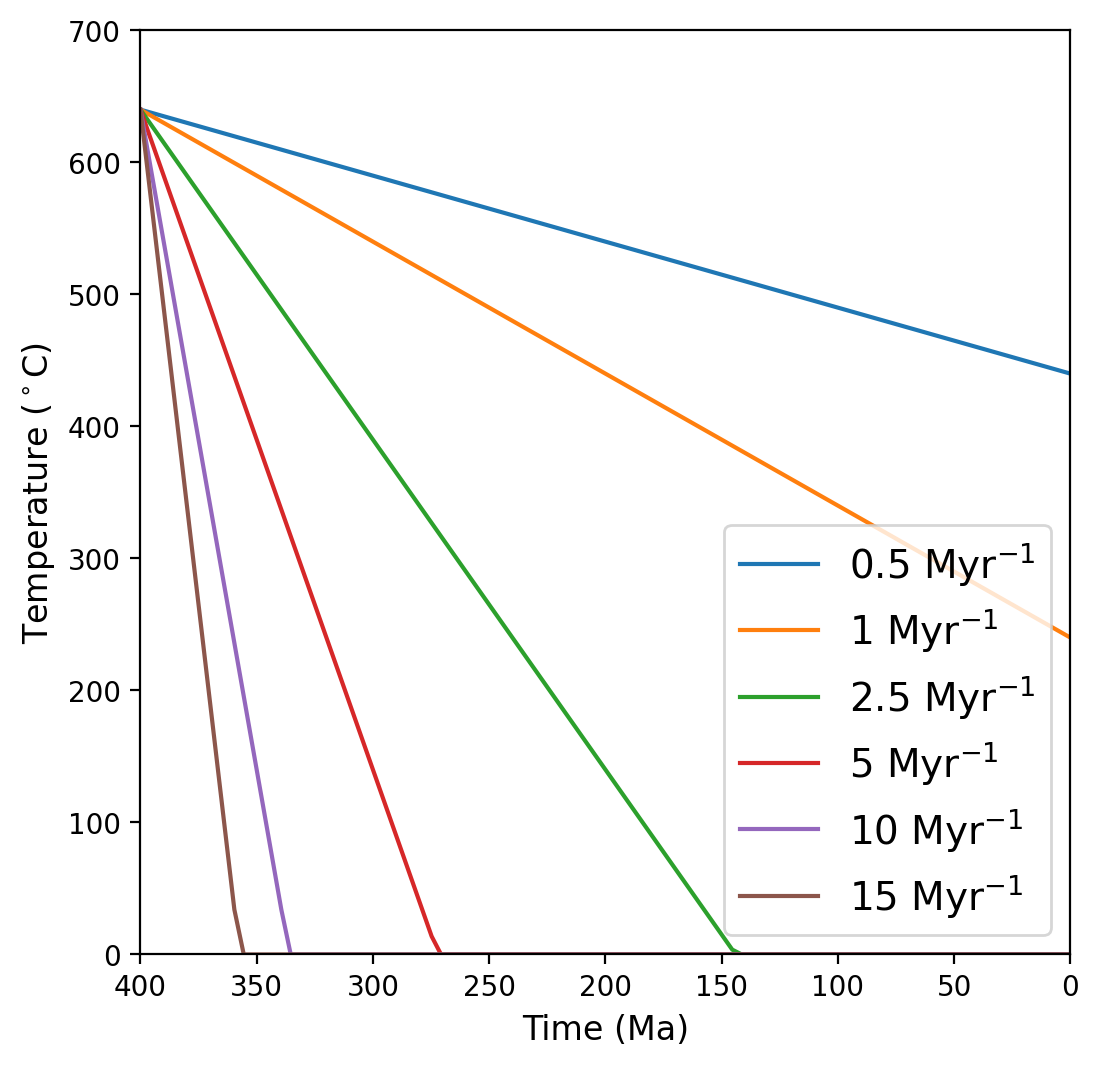

In [14]:
plt.figure(figsize=(6,6))
plt.plot(t_nodes, T_nodes_1, label = str(abs(cooling_rate[0]))+' Myr$^{-1}$')
plt.plot(t_nodes, T_nodes_2, label = str(abs(cooling_rate[1]))+' Myr$^{-1}$')
plt.plot(t_nodes, T_nodes_3, label = str(abs(cooling_rate[2]))+' Myr$^{-1}$')
plt.plot(t_nodes, T_nodes_4, label = str(abs(cooling_rate[3]))+' Myr$^{-1}$')
plt.plot(t_nodes, T_nodes_5, label = str(abs(cooling_rate[4]))+' Myr$^{-1}$')
plt.plot(t_nodes, T_nodes_6, label = str(abs(cooling_rate[5]))+' Myr$^{-1}$')

plt.xlim(0, 200)
plt.ylim(0, 700)

plt.xlabel('Time (Ma)', fontsize=12)
plt.ylabel('Temperature ($^\circ$C)', fontsize=12)
plt.xlim(max(t_nodes), min(t_nodes))
plt.legend(fontsize=14)
plt.show()

In [15]:
colors = ['purple', 'C0', 'darkgreen', 'lightgreen', 'C1', 'r']

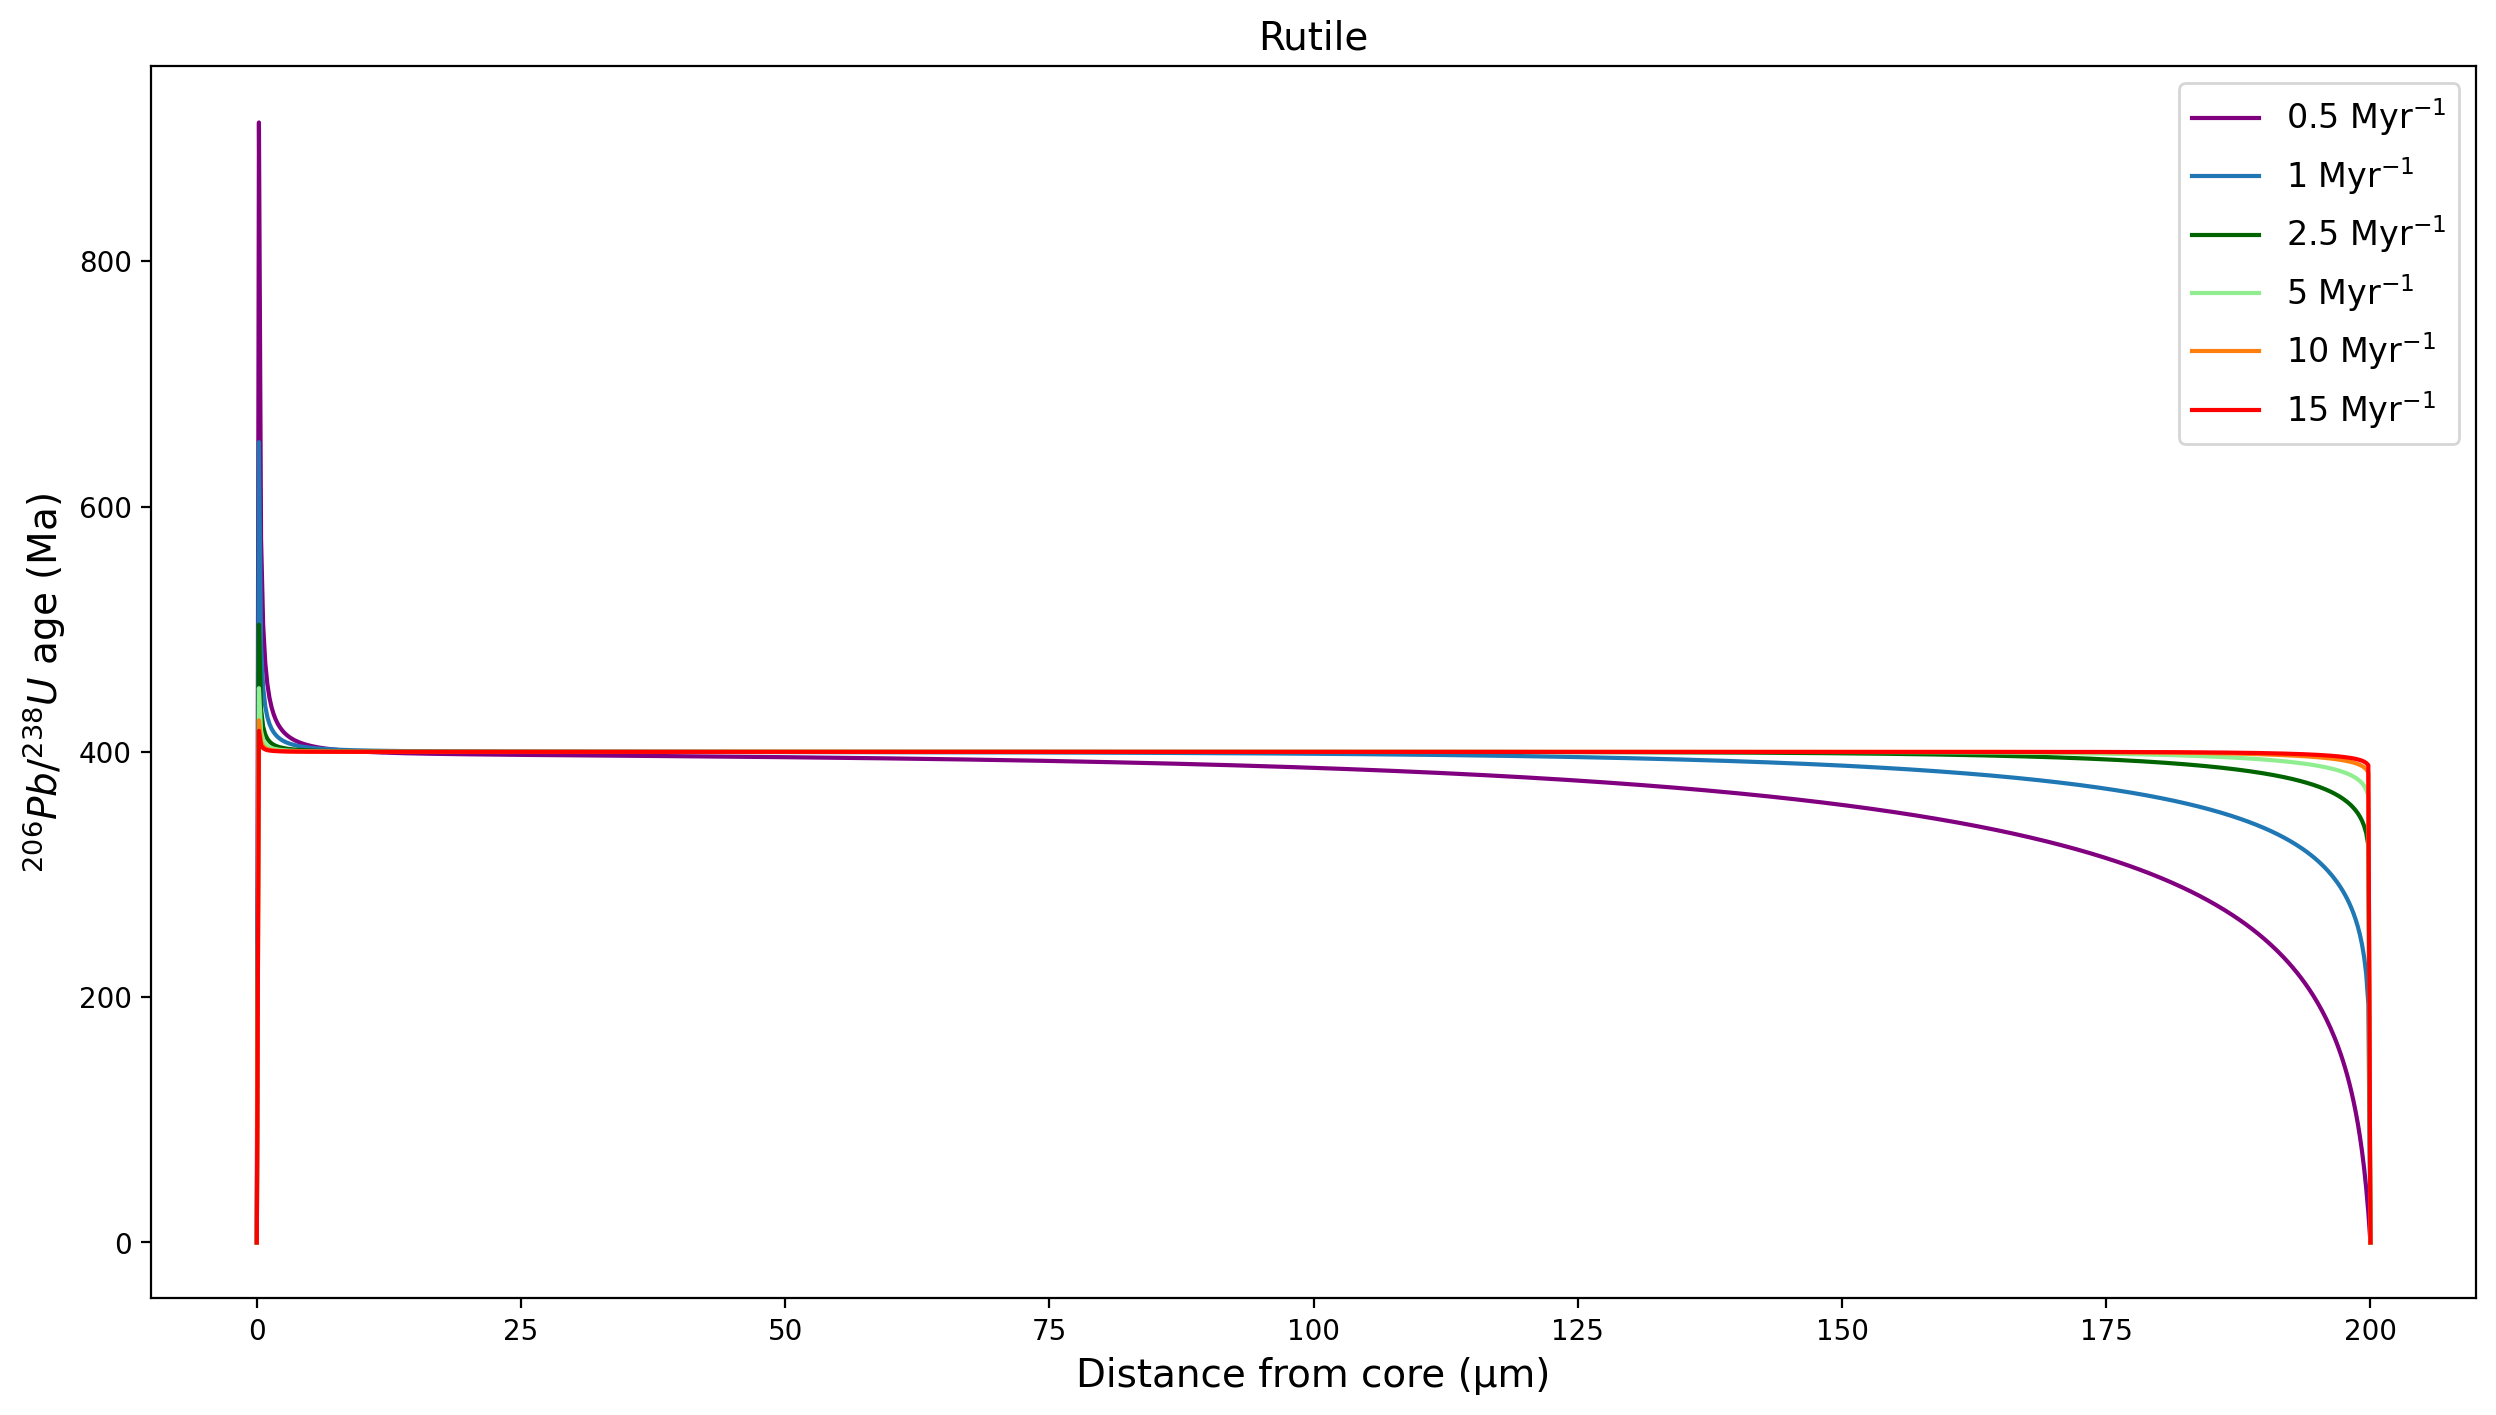

In [18]:
t = np.linspace(0, 200 ,1000)
plt.figure(figsize=(15,8))

T_nodes_list = [T_nodes_1, T_nodes_2, T_nodes_3, T_nodes_4, T_nodes_5, T_nodes_6]

for i in range(len(T_nodes_list)):
    
    T_nodes = T_nodes_list[i]
    Conc206_node, Age206_node, u_206_y, Conc206_node_t = Function_UPbDiff(t_nodes,
                                                                            T_nodes,
                                                                            25,
                                                                            rutile_E,
                                                                            rutile_D0,
                                                                            200, 
                                                                            1000)

    plt.plot(t, Age206_node, label = str(abs(cooling_rate[i]))+' Myr$^{-1}$', color=colors[i])
#     plt.plot(t[10:], Age206_node[10:])

# plt.xlim(100, 200)
# plt.ylim(20, 200)

plt.xlabel('Distance from core (µm)', fontsize=14)
plt.ylabel('$^{206}Pb/^{238}U$ age (Ma)', fontsize=14)
plt.legend(fontsize=12)
plt.title('Rutile', fontsize=14)
plt.show()

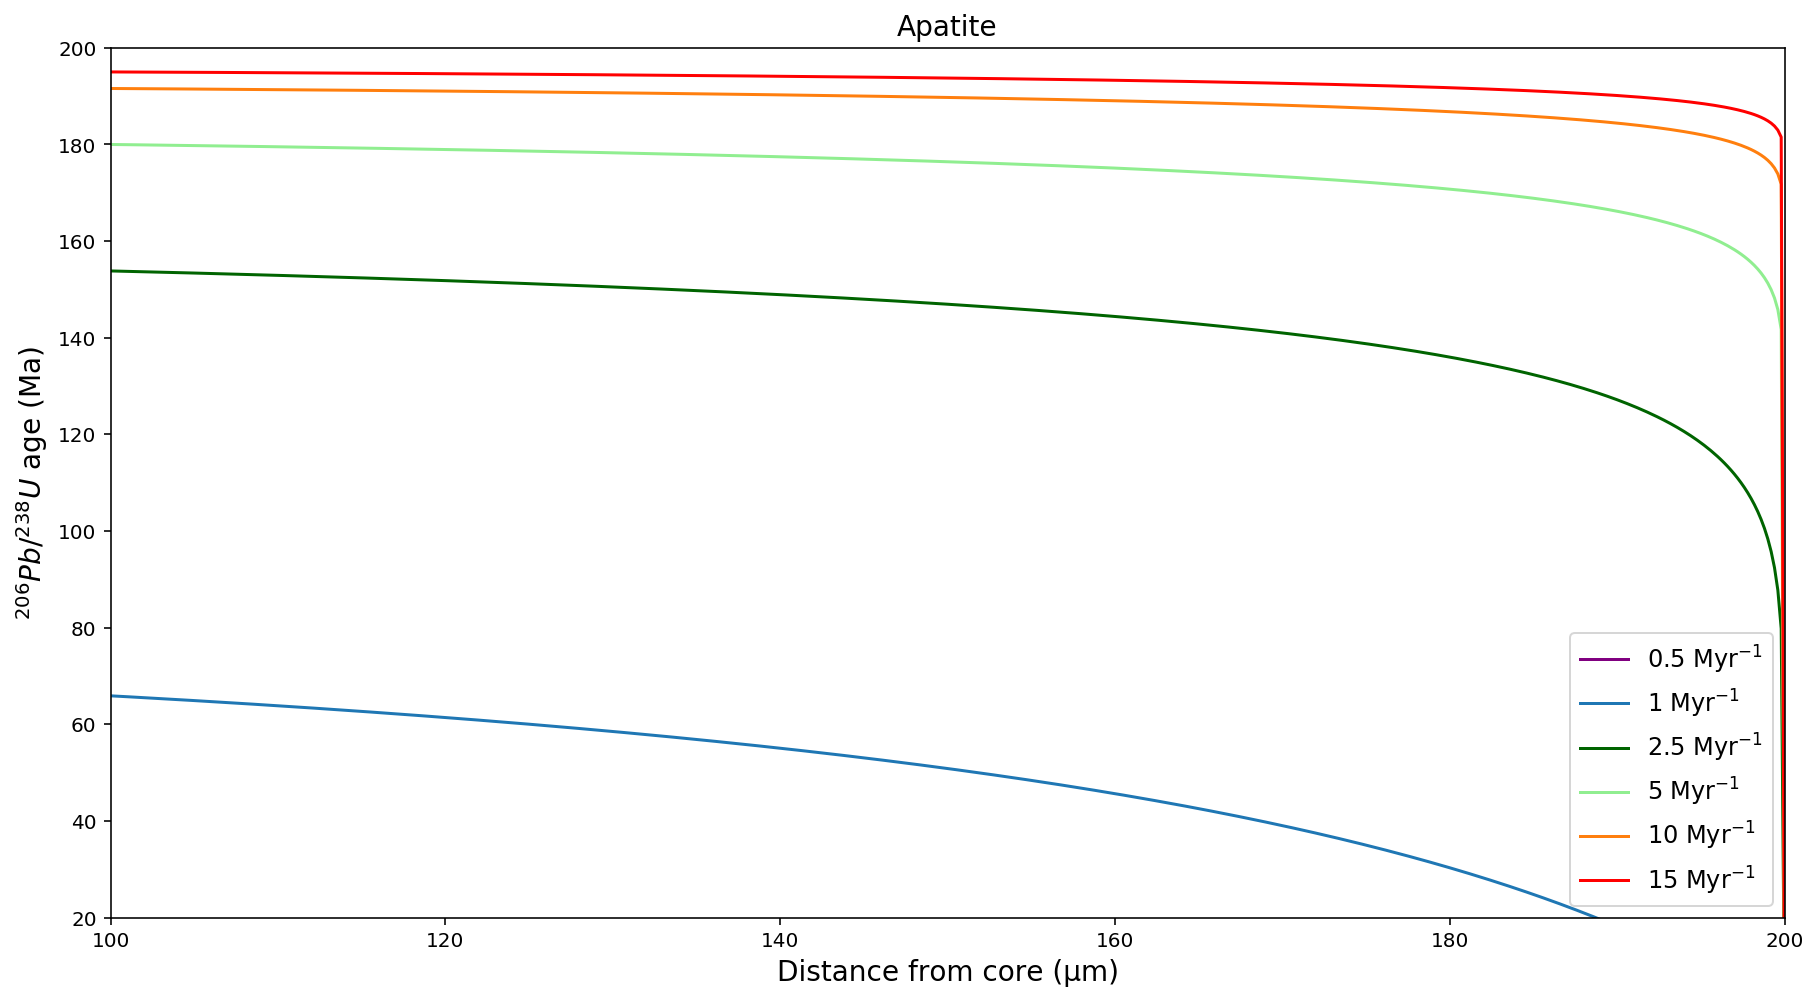

In [28]:
t = np.linspace(min(t_nodes), max(t_nodes),1000)
plt.figure(figsize=(15,8))

T_nodes_list = [T_nodes_1, T_nodes_2, T_nodes_3, T_nodes_4, T_nodes_5, T_nodes_6]

for i in range(len(T_nodes_list)):
    
    T_nodes = T_nodes_list[i]
    Conc206_node, Age206_node, u_206_y, Conc206_node_t = Function_UPbDiff(t_nodes,
                                                                            T_nodes,
                                                                            25,
                                                                            apatite_E,
                                                                            apatite_D0,
                                                                            200, 
                                                                            1000)

    plt.plot(t, Age206_node, label = str(abs(cooling_rate[i]))+' Myr$^{-1}$', color=colors[i])
#     plt.plot(t[10:], Age206_node[10:])

plt.xlim(100, 200)
plt.ylim(20, 200)

plt.xlabel('Distance from core (µm)', fontsize=14)
plt.ylabel('$^{206}Pb/^{238}U$ age (Ma)', fontsize=14)
plt.legend(fontsize=12)
plt.title('Apatite', fontsize=14)

plt.show()

In [ ]:
apatite = pd.read_csv('../file')
MA1_apatite = apatite[apatite['Sample'].str.contains('MA1')]
MA5_apatite = apatite[apatite['Sample'].str.contains('MA5')]

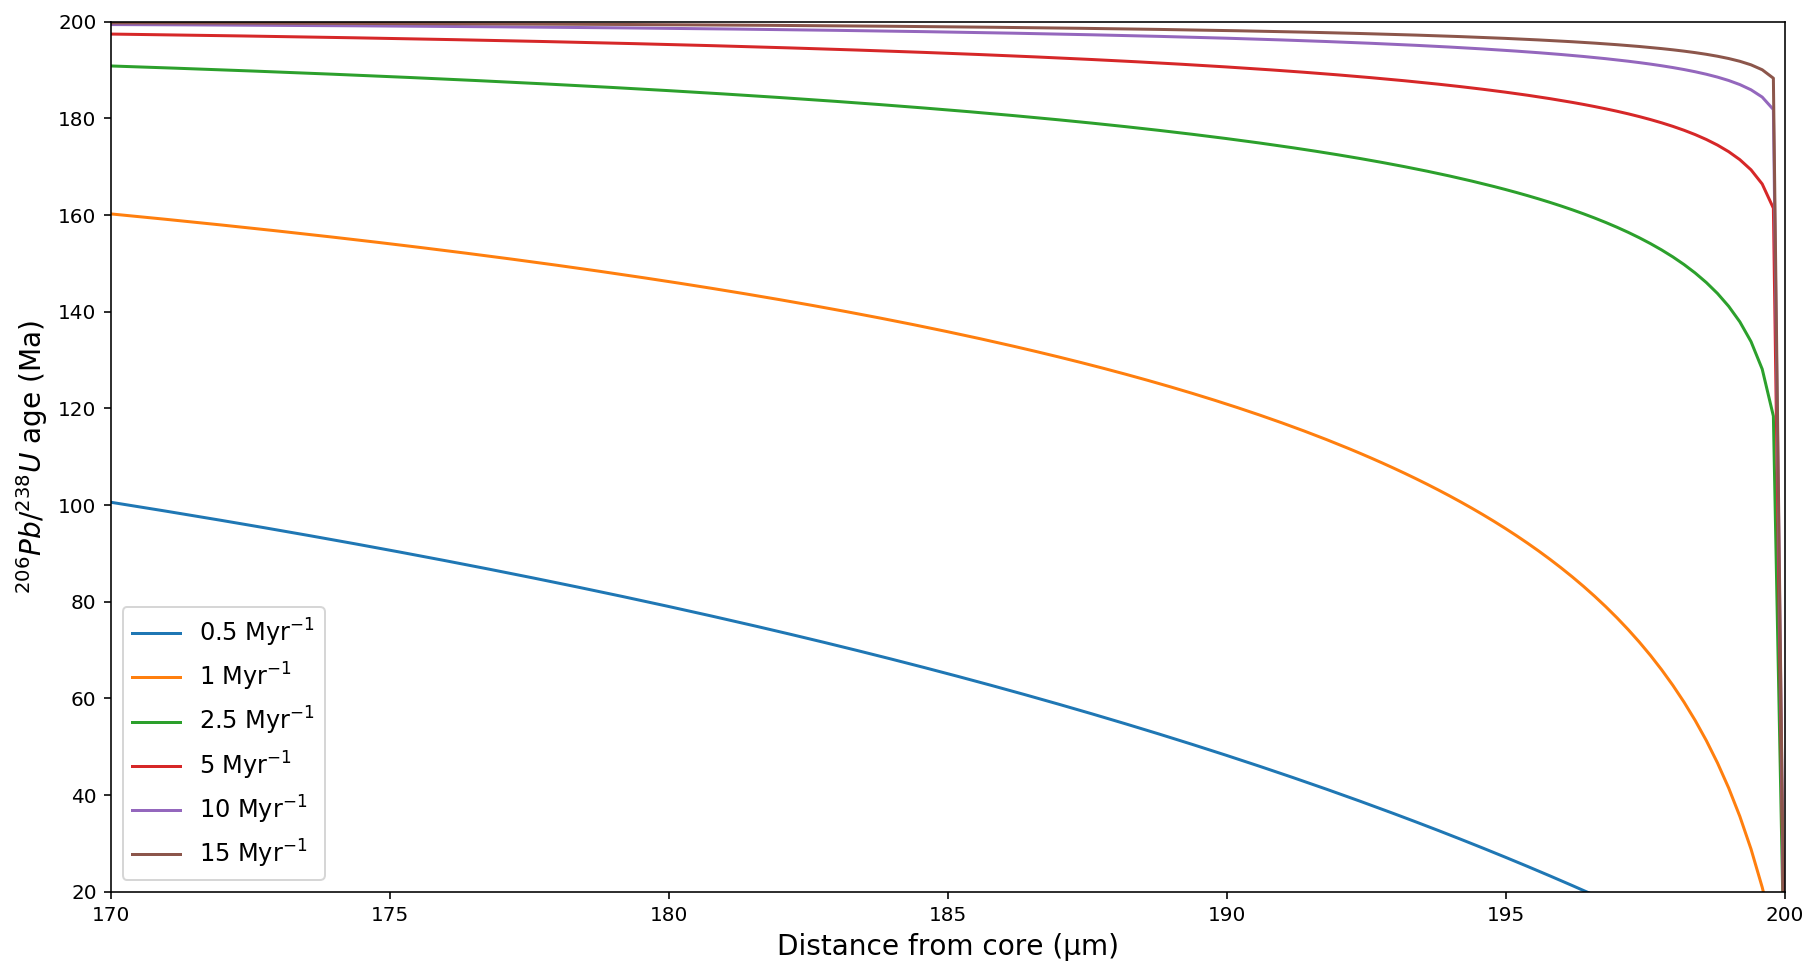

In [12]:
t = np.linspace(min(t_nodes), max(t_nodes),1000)
plt.figure(figsize=(15,8))

T_nodes_list = [T_nodes_1, T_nodes_2, T_nodes_3, T_nodes_4, T_nodes_5, T_nodes_6]

for i in range(len(T_nodes_list)):
    
    T_nodes = T_nodes_list[i]
    Conc206_node, Age206_node, u_206_y, Conc206_node_t = Function_UPbDiff(t_nodes,
                                                                            T_nodes,
                                                                            25,
                                                                            rutile_E,
                                                                            rutile_D0,
                                                                            133, 
                                                                            1000)

    plt.plot(t, Age206_node, label = str(abs(cooling_rate[i]))+' Myr$^{-1}$')
#     plt.plot(t[10:], Age206_node[10:])

plt.xlim(170, 200)
plt.ylim(20, 200)

plt.xlabel('Distance from core (µm)', fontsize=14)
plt.ylabel('$^{206}Pb/^{238}U$ age (Ma)', fontsize=14)
plt.legend(fontsize=12)
plt.show()

In [326]:
calc_effective_radius('cylindrical', 1e10, 400, )

{'geometry': 'cylindrical',
 'eff_r': 300.0,
 'surface': 12566371117013.998,
 'volume': 1256637061435917.2,
 'SV_ratio': 0.01}

In [327]:
def calc_effective_radius(geometry, L=0, W=0, H=0, T=0):
    '''
    calculates effective spherical radius
    
    required parameters: 
    L: length; for tetragonal prisms, report the full length as well as the tip length
    W: width
    H: height
    T: tip of the grain, used only for zircon prismatic grains
    
    returns: 
    eff_r: effective radius in cm
    geometry: geometry, 
    eff_r: r_sphere, 
    surface: Surface, cm^2
    volume: Volume, cm^2
    SV_ratio: surface to volume ratio
    
    '''
    
    assert geometry in ['sphere', 'ellipsoid', 'cylindrical', 'tetragonal prismatic', 'hexagonal prismatic']

    if geometry == 'sphere':
        r_sphere = (L+W)/4
        Surface = 4*np.pi*r_sphere**2
        Volume = 4/3*np.pi*r_sphere**3
    elif geometry == 'ellipsoid':
        p        = 1.6075  # parameter p for Ellipsoid Surface calculation
        Surface  = 4*np.pi*((H**p*W**p + H**p*L**p + W**p*L**p)/3)**(1/p)
        Volume   = 4/3*H*W*L*np.pi
        SV_ratio = Surface/Volume
        r_sphere = 3/SV_ratio
    elif geometry == 'cylindrical':
        Surface  = 2*np.pi*(W/2)*(W+L)
        Volume   = (W/2)**2*np.pi*L
        SV_ratio = Surface/Volume
        r_sphere = 3/SV_ratio
    elif geometry == 'tetragonal prismatic':
        if T == 0:
            Surface = 2*(W*L) + 2*(H*L) + 2*(H*W)
            Volume  = H*W*L
            SV_ratio  = Surface/Volume
        else:
            Surface_B = 2*(W*(L-2*T))+2*(H*(L-2*T))   # no basal planes for Surface area, Tip height substracted from overall Length!!!
            Volume_B  = H*W*(L-2*T)
            SL_W      = sqrt((H/2)**2 + T**2)     # calculate Side Length for Pyramid face (Base = width)
            SL_H      = sqrt((W/2)**2 + T**2)     # calculate Side Length for Pyramid face (Base = height)
            Surface_T = 2*(W*SL_W/2 + H*SL_H/2)   # add 2 pairs of Pyramid surfaces  
            Volume_T  = 1/3*H*W*T
            Volume = Volume_T + Volume_B
            Surface = Surface_T + Surface_B
            SV_ratio  = Surface/Volume

        r_sphere = 3/SV_ratio

    elif geometry == 'hexagonal prismatic':
        Surface  = 2*(3/2*sqrt(3)*(W/2)**2)+6*(W/2*L)
        Volume   = 3/2*sqrt(3)*(W/2)**2*L 
        SV_ratio = Surface/Volume
        r_sphere = 3/SV_ratio

    return {'geometry':geometry, 
            'eff_r':round(r_sphere,2), 
            'surface':Surface, 
            'volume':Volume, 
            'SV_ratio':round(SV_ratio,2)}

                    
                    

In [318]:
calc_effective_radius('tetragonal prismatic', 350, 110, 110, 0)

{'geometry': 'tetragonal prismatic',
 'eff_r': 71.3,
 'surface': 178200,
 'volume': 4235000,
 'SV_ratio': 0.04}